# 01 Data Exploration — Constraint Datasets

**PA1 ZHAW IUNR** | Bächler, Hofstetter, Reichlin | Supervisor: Patrick Laube

Quality assessment of datasets required for **exclusion masks** (02_Constraints_Mask.ipynb).
WLC datasets (solar, snow, grid, acceptance) are validated in notebook 03.

**Input:**
```
data/raw/dem/                   DEM (DHM25)
data/raw/permafrost/            Permafrost hazard map
data/raw/tlm3d/                 swissTLM3D (land cover, water bodies, buildings)
data/raw/hazards/               Natural hazard inventory GR
data/raw/protected_areas/       Protected areas (BLN, AULAV, UNESCO)
data/raw/swissboundaries/       Canton border GR
```


**Output:** Quality report → proceed with `02Constraints_Mask.ipynb` → `constraint_mask_s2.tif`

## 1. Setup & Imports

In [ ]:
#Import required libraries
from pathlib import Path                                                   # Cross-platform file path handling
import geopandas as gpd                                                    # Geospatial data manipulation (shapefiles, GeoJSON)
import pandas as pd                                                        # Tabular data analysis
import numpy as np                                                         # Numerical computing
import matplotlib.pyplot as plt                                            # Data visualization
import rasterio                                                            # Read/write raster data (GeoTIFF, etc.)
from rasterio.mask import mask                                             # Clip raster data with vector geometries
import fiona                                                               # Read/write vector data formats
import warnings
warnings.filterwarnings("ignore")                                          # Suppress non-critical warnings for cleaner output

#Plot configuration
plt.rcParams.update({
    "figure.dpi": 120,                                                     # Resolution: 120 DPI ensures crisp output when saved
    "font.size": 9,                                                        # Base font size: small enough for labels, readable on screen
    "axes.titlesize": 11                                                   # Title font size: slightly larger for emphasis
})



#Define data paths
RAW = Path("../data/raw")                                                 # Raw input data directory
OUT = Path("../outputs/figures")                                          # Figure output directory
OUT.mkdir(parents=True, exist_ok=True)                                     # Create output folder if missing

print("✓ Setup OK")

✓ Setup OK


## 2. Canton border GR

In [26]:

print("=== Kantonsgrenze GR ===\n") # Section header for canton boundary processing

#Load Swiss municipalities shapefile and identify canton code column
municipalities = gpd.read_file(RAW / "swissboundaries/swissboundaries_gemeinden.shp") # Load municipalities shapefile from raw data directory
canton_col = next(c for c in municipalities.columns if "KANT" in c.upper() or c.upper().startswith("KT"))# Dynamically identify canton code column (e.g., "KANTON", "KTNR", etc.) by searching for keywords in column names

#Filter for Graubünden and dissolve into single boundary polygon
# Canton code: 18 = Graubünden (GR)
gr_muni = municipalities[municipalities[canton_col] == 18.0].copy() # Filter for GR municipalities, create copy to avoid SettingWithCopyWarning

# Merge all municipality geometries into one boundary polygon
gr_border = gpd.GeoDataFrame(
    {"geometry": [gr_muni.unary_union]},                                   # Union of all geometries
    crs=gr_muni.crs                                                        # Preserve coordinate reference system
)

#Output summary information about the canton boundary
display(f"GR: {len(gr_muni)} Gemeinden | {gr_border.area.sum()/1e6:.0f} km² | CRS: {gr_muni.crs}")

=== Kantonsgrenze GR ===



'GR: 100 Gemeinden | 7105 km² | CRS: EPSG:2056'

## 3. Summary Table - Raster Datasets

In [25]:
summary = []  # Initialize empty list to store raster validation results

def check_raster(name, path):
    # Function: validates a raster file and appends statistics to summary table
    # Parameters: name (dataset name), path (directory path to search for .tif file)
    
    tifs = sorted(path.glob("*.tif"))[:1]  # Search for GeoTIFF files, sort alphabetically, take first result
    
    if not tifs:  # If no .tif file found in directory
        summary.append({"Dataset": name, "Data": "Missing", "CRS OK": "—"})  # Record missing file status
        return  # Exit function early to avoid errors
    
    with rasterio.open(tifs[0]) as src:  # Open raster file with context manager
        d = src.read(1, masked=True)  # Read band 1 with mask applied (preserves nodata values)
        v = d.compressed()  # Extract only valid (non-masked) pixel values into array
        
        summary.append({  # Append dictionary with raster metadata to summary list
            "Dataset": name,  # Dataset name
            "Data": tifs[0].name,  # Filename
            "CRS": str(src.crs),  # Coordinate reference system as string
            "Resolution": f"{src.res[0]:.0f}m",  # Pixel resolution in meters (rounded to integer)
            "Min": f"{v.min():.1f}" if v.size else "—",  # Minimum pixel value (1 decimal place, or "—" if empty)
            "Max": f"{v.max():.1f}" if v.size else "—",  # Maximum pixel value (1 decimal place, or "—" if empty)
            "NoData%": f"{d.mask.sum()/d.size*100:.1f}",  # Percentage of nodata/masked pixels (1 decimal place)
            "CRS OK": "✓" if src.crs.to_epsg() == 2056 else "✗"  # Validation: check if CRS matches expected LV95 (EPSG:2056)
        })

check_raster("DHM25", RAW / "dem")  # Validate DEM (DHM25) dataset
check_raster("Permafrost", RAW / "permafrost")  # Validate Permafrost hazard map dataset

df_summary = pd.DataFrame(summary).fillna("—")  # Convert list of dictionaries to DataFrame, replace NaN with "—"

display(df_summary) # Display summary table of raster validation results

,Dataset,Data,CRS OK,CRS,Resolution,Min,Max,NoData%
0,DHM25,Missing,—,—,—,—,—,—
1,Permafrost,permafrost_2056.tif,✓,EPSG:2056,25m,0.0,5.0,96.4


## DHM25 findet es nicht???? Warum?? und Permafrost nur 3.4% stimmt das für Graubünden? ##

## 4. swissTLM3D - Layer Inventory

In [27]:
print("=== swissTLM3D — Layer Inventory ===\n") # Section header for swissTLM3D GeoPackage layer inventory

# Determine GPKG path (may be a directory containing the actual .gpkg file)
tlm_path = RAW / "tlm3d/swisstlm3d_2026-02-24_2056_5728.gpkg"
if tlm_path.is_dir():  # If path is a folder, search inside for .gpkg file
    tlm_path = next(tlm_path.glob("*.gpkg"))

# List all available layers in the GeoPackage database
layers = fiona.listlayers(str(tlm_path))

# Define which layers are required for constraint mask generation
constraint_layers = {  # Layers needed for exclusion criteria (C06-C20)
    "tlm_bb_bodenbedeckung",           # Land cover/surface type
    "tlm_gewaesser_fliessgewaesser",   # Rivers and flowing water
    "tlm_gewaesser_stehendes_gewaesser",  # Lakes and standing water
    "tlm_bauten_gebaeude_footprint"    # Building footprints
}

# Inventory all layers: name, feature count, geometry type, constraint status
tlm_info = []
for lyr in layers:
    with fiona.open(str(tlm_path), layer=lyr) as src:
        tlm_info.append({
            "Layer": lyr,  # Layer name in GeoPackage
            "Features": len(src),  # Total number of features/geometries in layer
            "Geometry": src.schema["geometry"],  # Geometry type (Polygon, LineString, Point, etc.)
            "Constraint": "✓" if lyr in constraint_layers else ""  # Mark layers used for constraint criteria
        })

# Display layer inventory as table
df_tlm = pd.DataFrame(tlm_info)

display(df_tlm)# Display summary table of GeoPackage layers and their attributes

=== swissTLM3D — Layer Inventory ===



,Layer,Features,Geometry,Constraint
0,tlm_areale_nutzungsareal,36368,3D Polygon,
1,tlm_areale_freizeitareal,3400,3D Polygon,
2,tlm_areale_verkehrsareal,15167,3D Polygon,
3,tlm_areale_schutzgebiet,2,3D Polygon,
4,tlm_bauten_gebaeude_footprint,4125163,3D Polygon,✓
5,tlm_bauten_sportbaute_lin,3160,3D LineString,
6,tlm_bauten_sportbaute_ply,16641,3D Polygon,
7,tlm_bauten_staubaute,73219,3D Polygon,
8,tlm_bauten_verbauung,83109,3D LineString,
9,tlm_bauten_verkehrsbaute_lin,1966,3D LineString,


## 5. Land cover — Translate “forest, glacier, settlement”

In [ ]:
print("=== Land Cover — Forest, Glacier, Settlement ===\n") # Section header for land cover layer exploration and summary statistics

# Load land cover layer and clip to GR canton boundary
bb_layer = next(lyr for lyr in fiona.listlayers(str(tlm_path)) if "bodenbedeckung" in lyr.lower())# Dynamically identify land cover layer by searching for "bodenbedeckung" in layer names (case-insensitive)
bodenbedeckung = gpd.read_file(str(tlm_path), layer=bb_layer)  # Read GeoPackage layer into GeoDataFrame
bodenbedeckung = gpd.clip(bodenbedeckung, gr_border.to_crs(bodenbedeckung.crs))  # Clip to GR canton boundary using coordinate transformation
cat_col = next(c for c in bodenbedeckung.columns if "art" in c.lower() or "klasse" in c.lower())  # Dynamically identify category/classification column

print(f"Layer: {bb_layer} | Column: {cat_col} | Features: {len(bodenbedeckung)}\n")# Output basic information about the land cover layer and identified category column

# For each category: feature count and area in km²
for cat, group in bodenbedeckung.groupby(cat_col):# Group features by category/classification and calculate summary statistics
    print(f"  {str(cat):30s} {len(group):>6d} Features  {group.area.sum()/1e6:>8.1f} km²")# Print category name, feature count, and total area (converted to km²) with formatted output

=== Land Cover — Forest, Glacier, Settlement ===

Layer: tlm_bb_bodenbedeckung | Column: objektart | Features: 210698

  Fels                            67353 Features     822.6 km²
  Fels locker                     13342 Features      75.7 km²
  Felsbloecke                       930 Features       8.1 km²
  Felsbloecke locker                357 Features       2.7 km²
  Feuchtgebiet                     4447 Features      37.7 km²
  Fliessgewaesser                   140 Features      15.2 km²
  Gebueschwald                    11875 Features     197.6 km²
  Gehoelzflaeche                  26261 Features      17.1 km²
  Gletscher                         424 Features      88.7 km²
  Lockergestein                   45159 Features    1212.7 km²
  Lockergestein locker            15251 Features     137.4 km²
  Schneefeld Toteis                 876 Features       4.6 km²
  Stehende Gewaesser               3594 Features      32.9 km²
  Wald                            15409 Features    1614.8 km²

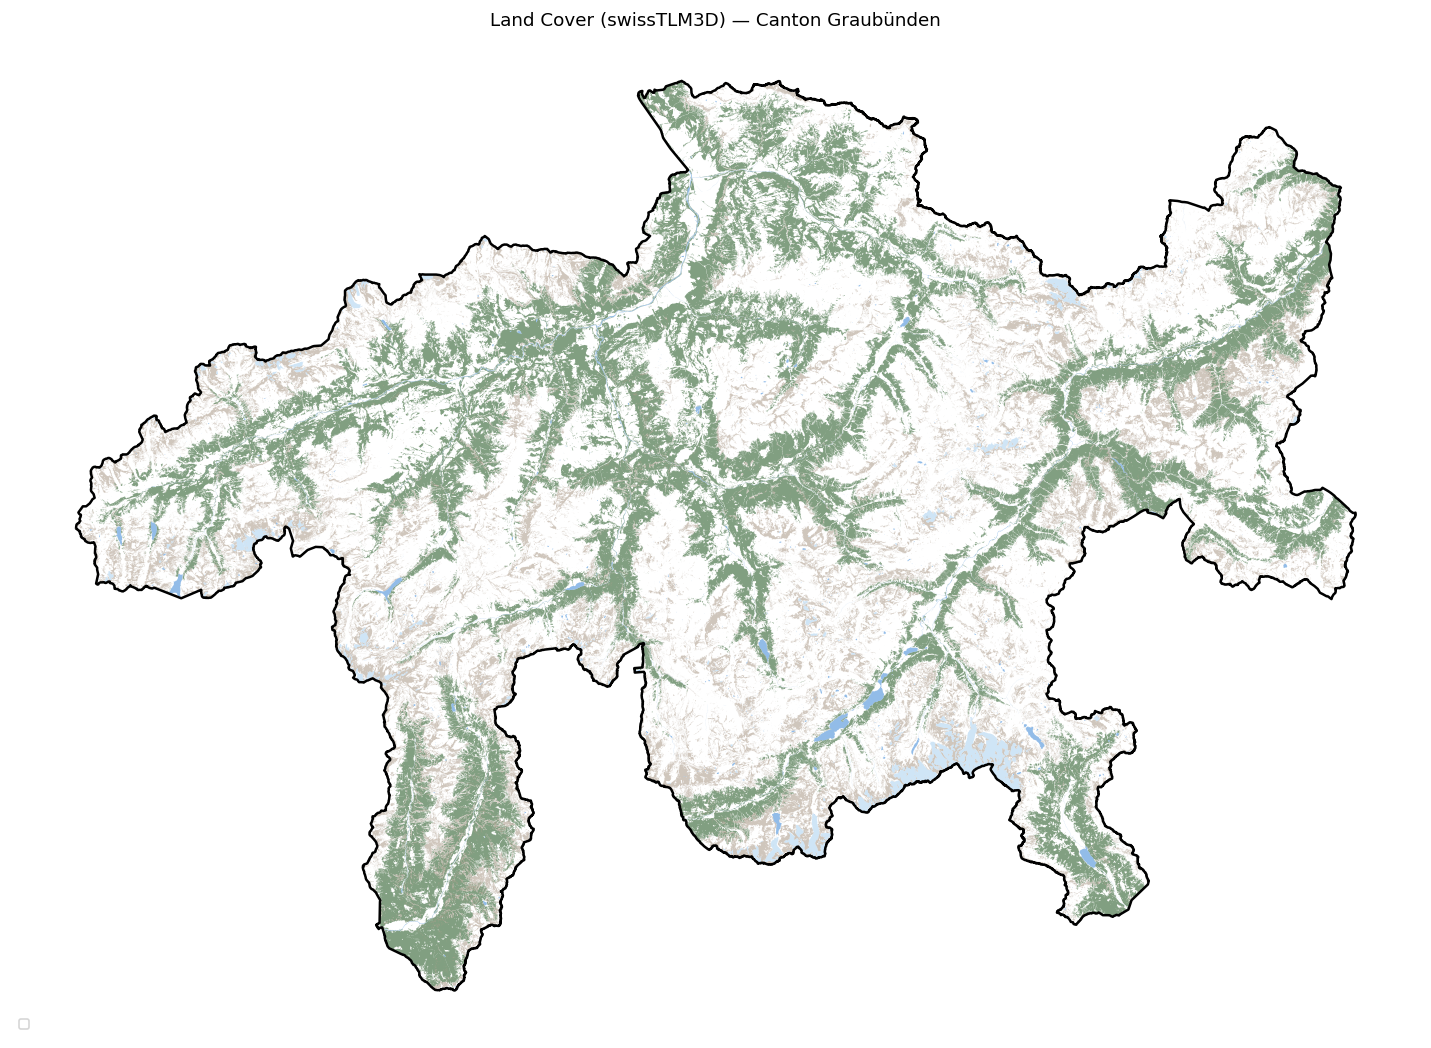

In [17]:
# Land Cover Map
fig, ax = plt.subplots(figsize=(12, 10)) # Create figure and axis for plotting with specified size
gr_border.boundary.plot(ax=ax, color="black", linewidth=1.5)               # Draw canton boundary as black outline with specified line width

colors = {"Wald": "#2D5F2D", "Fels": "#B0A090", "Gletscher": "#B0D4F1", # Define colors for land cover categories (forest, rock, glacier, water, buildings)
          "Gewaesser": "#4A90D9", "Gebaeude": "#D45050"}

for key, color in colors.items():
    sub = bodenbedeckung[bodenbedeckung[cat_col].str.contains(key, case=False, na=False)] # Filter features that contain the category keyword (case-insensitive, handle NaN)
    if not sub.empty:
        sub.plot(ax=ax, color=color, alpha=0.6, label=key)                 # Category mapped to color with transparency, add legend label

ax.legend(loc="lower left", fontsize=8)
ax.set_title("Land Cover (swissTLM3D) — Canton Graubünden")
ax.set_axis_off()
plt.tight_layout()
fig.savefig(OUT / "bodenbedeckung_gr.png", dpi=150, bbox_inches="tight")   # Export

## 6. DEM — Elevation Distribution and Derivatives

=== DEM — Elevation Distribution and Derivatives ===

DEM: 255–4043 m | 25m | (4011, 5642)
  1500–2700 m             5008 km² (70.5%)
  Slope < 35°             5205 km² (73.3%)
  Aspect 120–240°         2315 km² (32.6%)


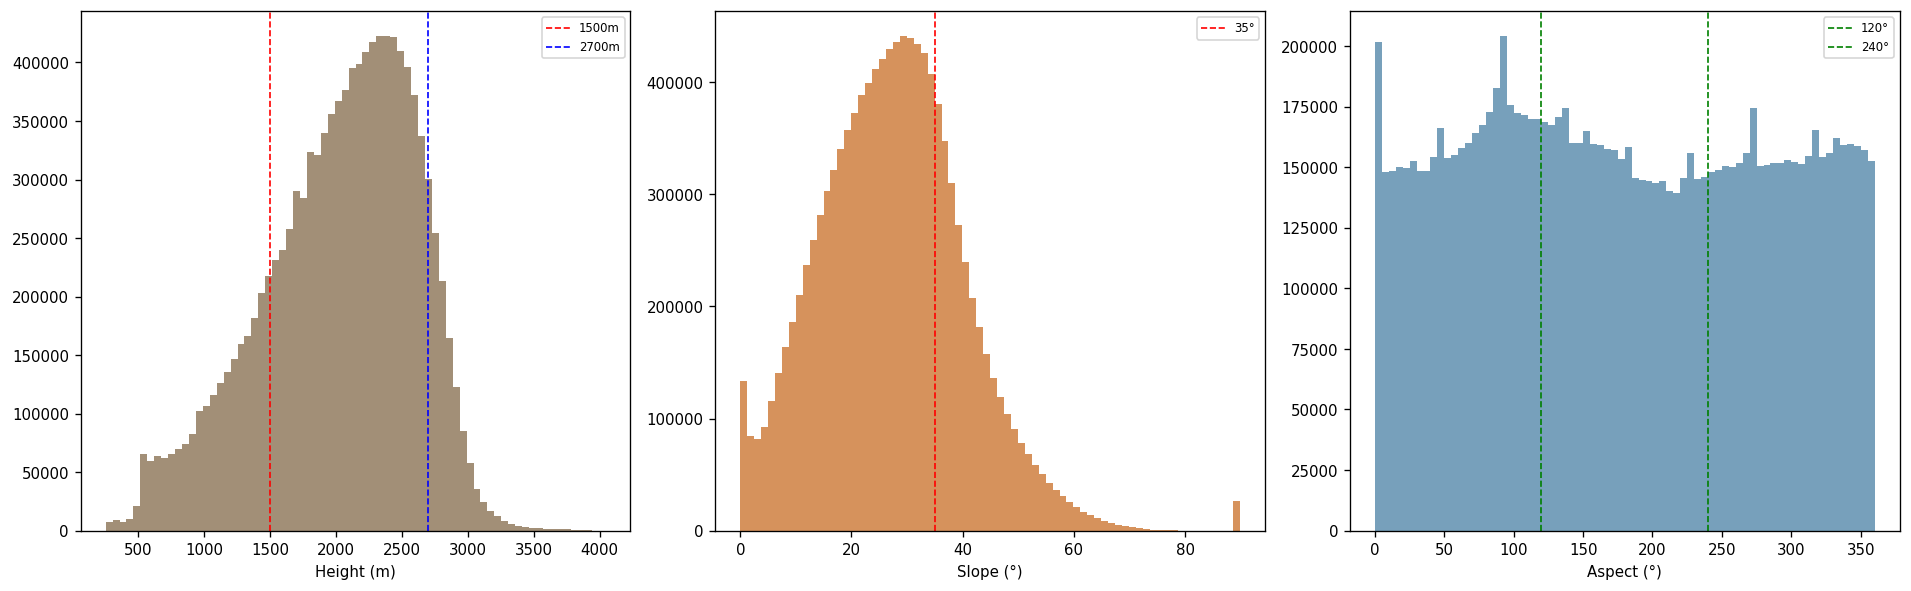

In [18]:
print("=== DEM — Elevation Distribution and Derivatives ===\n")

# Search for DEM file (.tif or .asc format)
dem_path = next((RAW / "dem").glob("*.tif"), None)  # First search for GeoTIFF format files (.tif) in DEM directory
if not dem_path:  # If no .tif found, search for ASCII grid format
    dem_path = next((RAW / "dem").glob("**/*.asc"), None)  # Recursively search for .asc files in subdirectories
if not dem_path:  # If neither format found
    raise FileNotFoundError("No DEM file found in data/raw/dem/")  # Raise error with descriptive message

# Clip DEM to GR canton boundary extent
with rasterio.open(dem_path) as src:  # Open DEM raster file with context manager
    gr_clip = gr_border.to_crs(src.crs) if src.crs and src.crs != gr_border.crs else gr_border  # Reproject GR boundary to match DEM CRS if needed
    dem, dem_tf = mask(src, [gr_clip.geometry.iloc[0].__geo_interface__], crop=True, nodata=src.nodata)  # Clip DEM to GR boundary, crop to minimal extent, preserve nodata values
    dem = dem[0].astype(float)  # Extract first band and convert to float data type
    valid = np.isfinite(dem) & ((dem != src.nodata) if src.nodata else np.ones_like(dem, dtype=bool))  # Create boolean mask: valid pixels = finite values excluding nodata
    px_area = src.res[0] * src.res[1] / 1e6  # Calculate pixel area in km² (resolution² / 1,000,000)

# Calculate Slope and Aspect using finite-difference method
dem_v = dem[valid]  # Extract only valid (non-nodata) elevation values
dy, dx = np.gradient(dem, src.res[0])  # Calculate elevation gradient in y and x directions (using pixel resolution)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))  # Compute slope in degrees: inverse tangent of gradient magnitude
aspect = np.degrees(np.arctan2(-dx, dy)) % 360  # Compute aspect in degrees [0-360]: inverse tangent2 of direction vectors
print(f"DEM: {dem_v.min():.0f}–{dem_v.max():.0f} m | {src.res[0]:.0f}m | {dem.shape}")  # Output: elevation range, pixel resolution, array dimensions

# Create three-panel histogram: Height, Slope, Aspect
fig, axes = plt.subplots(1, 3, figsize=(16, 5))  # Create figure with 1 row and 3 columns of subplots, 16x5 inch size
for ax, data, lbl, col, vlines in [
    (axes[0], dem_v, "Height (m)", "#8B7355", [(1500, "r", "1500m"), (2700, "b", "2700m")]),  # Subplot 1: elevation with min/max thresholds
    (axes[1], slope[valid], "Slope (°)", "#CC7733", [(35, "r", "35°")]),  # Subplot 2: slope with steepness threshold
    (axes[2], aspect[valid], "Aspect (°)", "#5588AA", [(120, "g", "120°"), (240, "g", "240°")]),  # Subplot 3: aspect with N-facing range (120-240°)
]:
    ax.hist(data, bins=72, color=col, edgecolor="none", alpha=0.8)  # Draw histogram: 72 bins, solid color, 80% transparency
    for v, c, l in vlines:  # Iterate over threshold values
        ax.axvline(v, color=c, ls="--", lw=1, label=l)  # Draw vertical dashed line at threshold with color and label
    ax.set_xlabel(lbl)  # Set x-axis label (Height, Slope, or Aspect)
    ax.legend(fontsize=7)  # Display legend with small font size
plt.tight_layout()  # Adjust subplot spacing to prevent label overlap
fig.savefig(OUT / "dem_analyse_gr.png", dpi=150, bbox_inches="tight")  # Export figure to PNG: 150 DPI, tight bounding box

# Calculate area statistics for three constraint criteria
for label, count in [
    ("1500–2700 m", ((dem_v >= 1500) & (dem_v <= 2700)).sum()),  # Count pixels within elevation range: suitable altitude zone
    ("Slope < 35°", (slope[valid] < 35).sum()),  # Count pixels below slope threshold: buildable gradient
    ("Aspect 120–240°", ((aspect[valid] >= 120) & (aspect[valid] <= 240)).sum()),  # Count pixels in N-facing range: north-facing slopes
]:
    print(f"  {label:20s} {count*px_area:>7.0f} km² ({count/dem_v.size*100:.1f}%)")  # Output: criterion name, area in km², percentage of total

## 7. Permafrost Map

In [19]:
print("=== Permafrost Indicator Map ===\n")

# Search for permafrost raster file in directory
pf_path = next((RAW / "permafrost").glob("*.tif"), None)  # Search for GeoTIFF format permafrost hazard map
if not pf_path:  # If no permafrost file found
    print("⚠ Permafrost file not found")  # Print warning message
else:  # If permafrost file exists
    with rasterio.open(pf_path) as src:  # Open raster file with context manager
        v = src.read(1, masked=True).compressed()  # Read band 1 with mask applied, extract valid (non-masked) pixel values
    print(f"CRS: {src.crs} | {src.res[0]:.0f}m | Values: {v.min():.0f}–{v.max():.0f}")  # Output CRS, resolution, min/max pixel values
    
    # Interpret pixel values: determine if raster contains elevation thresholds, discrete classes, or continuous data
    if v.min() > 1000:  # If minimum value > 1000 → likely elevation threshold (height in meters)
        print(f"→ Elevation values (Permafrost lower threshold). Exclusion: DEM ≥ Value")  # Interpretation: use as elevation cutoff
    elif len(np.unique(v)) <= 10:  # If ≤10 unique values → discrete classification system
        print(f"→ Classes: {np.unique(v)}")  # Print unique class values
    else:  # Otherwise: continuous or many-valued raster
        print(f"→ {len(np.unique(v))} unique values (continuous data)")  # Print count of unique pixel values

=== Permafrost Indicator Map ===

CRS: EPSG:2056 | 25m | Values: 0–5
→ Classes: [0 1 2 3 4 5]


## 8. Natural Hazards (Geodienste.ch)

In [20]:
print("=== Natural Hazards (Geodienste.ch) ===\n")

# Define base path and hazard types dictionary
hazard_base = RAW / "hazards/naturereigniskataster_v1_0_GR_csv_lv95(1)/csv/naturereigniskataster_v1_0"  # Base directory path for natural hazard inventory files
hazard_csvs = {  # Dictionary mapping hazard type labels to corresponding CSV filenames
    "Avalanches": "prozessraum_lawine.csv",  # Avalanche process areas
    "Rock Fall": "prozessraum_sturz.csv",  # Rock fall and rockslide process areas
    "Landslides": "prozessraum_rutschung.csv",  # Landslide process areas
    "Floods": "prozessraum_wasser_ueberschwemmung_uebermurung.csv",  # Flood and debris flow process areas
}

# Load base geometry data (coordinates in Swiss LV95 system)
df_basis = pd.read_csv(  # Read CSV file containing base point geometries
    hazard_base / "basisinformation.csv", sep=";",  # Use semicolon as delimiter (European CSV standard)
    usecols=["primaerschluessel_bi_id", "E", "N"]  # Select only primary key ID and E/N coordinate columns
)
print(f"Base geometries: {len(df_basis)}\n")  # Output total number of base geometry points

# Process each hazard type: join with base geometries and calculate statistics
hazard_info = []  # Initialize empty list to store hazard summary information
for label, filename in hazard_csvs.items():  # Iterate over each hazard type
    csv_path = hazard_base / filename  # Construct full file path for this hazard type CSV
    if not csv_path.exists():  # Skip if CSV file does not exist
        continue  # Move to next hazard type
    df_h = pd.read_csv(csv_path, sep=";")  # Load hazard-specific CSV data with semicolon delimiter
    fk_col = next((c for c in df_h.columns if "fremdschluessel_bi_id" in c.lower()), None)  # Dynamically identify foreign key column (usually "fremdschluessel_bi_id")
    merged = df_h.merge(df_basis, left_on=fk_col, right_on="primaerschluessel_bi_id", how="left") if fk_col else df_h  # Join hazard data with base geometries on foreign key to add E/N coordinates
    n_geom = merged[["E", "N"]].notna().all(axis=1).sum() if fk_col else 0  # Count features that have valid E/N coordinates (non-null in both columns)
    hazard_info.append({"Type": label, "File": filename, "Entries": len(df_h), "With Coordinates": n_geom})  # Append summary dictionary: label, filename, total entries, entries with coordinates
    print(f"{label}: {len(df_h)} entries, {n_geom} with E/N coordinates")  # Output hazard type summary: name, total count, count with geometries

pd.DataFrame(hazard_info)  # Convert list of dictionaries to DataFrame and display as table

=== Natural Hazards (Geodienste.ch) ===

Base geometries: 17302

Avalanches: 11454 entries, 11454 with E/N coordinates
Rock Fall: 3155 entries, 3155 with E/N coordinates
Landslides: 2050 entries, 2050 with E/N coordinates
Floods: 2241 entries, 2241 with E/N coordinates


,Type,File,Entries,With Coordinates
0,Avalanches,prozessraum_lawine.csv,11454,11454
1,Rock Fall,prozessraum_sturz.csv,3155,3155
2,Landslides,prozessraum_rutschung.csv,2050,2050
3,Floods,prozessraum_wasser_ueberschwemmung_uebermurung.csv,2241,2241


## 9. Protected Areas (BAFU)

In [21]:
print("=== Protected Areas (BAFU) ===\n")

# Define protected area shapefile paths: BLN, AULAV, Biosphere Reserves, UNESCO World Heritage
protected_files = {  # Dictionary mapping protected area labels to their file paths
    "BLN": RAW / "protected_areas/bundesinventare-bln_2056.shp",  # BLN (Federal Inventory of Landscapes/Monuments) — Swiss national heritage sites
    "AULAV": RAW / "protected_areas/schutzgebiete-aulav_2056.shp",  # AULAV (Inventory of Landscapes and Natural Monuments) — cantonal protected areas
    "Biosphere Reserves": RAW / "protected_areas/schutzgebiete-biosphaerenreservate_2056.shp",  # UNESCO biosphere reserves in Switzerland
    "UNESCO": RAW / "protected_areas/unesco-weltnaturerbe_2056.shp",  # UNESCO World Natural Heritage sites (e.g., Tectonic Arena Sardona)
}

# Process each protected area dataset
schutz_info = []  # Initialize empty list to store protected area summary information
for label, fpath in protected_files.items():  # Iterate over each protected area type
    if not fpath.exists():  # Check if file exists at specified path
        schutz_info.append({"Type": label, "File": "MISSING", "Features": 0})  # Record missing file status
        continue  # Skip to next protected area type
    gdf = gpd.read_file(fpath)  # Load shapefile into GeoDataFrame
    gdf_gr = gpd.clip(gdf.to_crs(gr_border.crs), gr_border)  # Reproject to GR CRS and clip to canton boundary
    area = gdf_gr.area.sum() / 1e6  # Calculate total area in km² (sum of all clipped geometries / 1,000,000)
    schutz_info.append({  # Append summary dictionary to list
        "Type": label, "File": fpath.name, "Features (Total)": len(gdf),  # Protected area type, filename, total feature count
        "Features (GR)": len(gdf_gr), "Area GR (km²)": f"{area:.1f}"  # Features within GR canton, area in km² (1 decimal place)
    })
    print(f"{label}: {len(gdf_gr)} Features in GR, {area:.1f} km²")  # Output summary: name, feature count within GR, area

pd.DataFrame(schutz_info)  # Convert list of dictionaries to DataFrame and display as table

=== Protected Areas (BAFU) ===

BLN: 18 Features in GR, 1283.9 km²
AULAV: 74 Features in GR, 64.6 km²
Biosphere Reserves: 3 Features in GR, 448.7 km²
UNESCO: 1 Features in GR, 45.6 km²


,Type,File,Features (Total),Features (GR),Area GR (km²)
0,BLN,bundesinventare-bln_2056.shp,174,18,1283.9
1,AULAV,schutzgebiete-aulav_2056.shp,326,74,64.6
2,Biosphere Reserves,schutzgebiete-biosphaerenreservate_2056.shp,6,3,448.7
3,UNESCO,unesco-weltnaturerbe_2056.shp,8,1,45.6


## 10. MCE Overview — All Constraint Datasets

In [24]:
print("=== MCE Overview: Constraint Datasets for Preprocessing ===\n")

# Define helper functions for checking file existence and reading raster resolution
def _ok(p):  # Function: check if file path exists (returns ✓ or ✗ symbol)
    return "✓" if (p is not None and Path(p).exists()) else "✗"

def _res(p):  # Function: read raster resolution from file metadata
    if p and Path(p).exists():  # Only proceed if path exists
        with rasterio.open(p) as ds:  # Open raster file
            return f"{ds.res[0]:.0f} m"  # Return resolution in meters (rounded)
    return "—"  # Return dash if file missing

# Dynamically extract metadata from previous sections
_dem_res = _res(dem_path)  # DEM resolution from Section 6
_pf_res  = _res(pf_path) if pf_path else "—"  # Permafrost resolution from Section 7
_aulav   = protected_files["AULAV"]  # AULAV file path from Section 9
_aulav_shps = sorted(_aulav.glob("*.shp")) if _aulav.is_dir() else []  # Count AULAV sublayer shapefiles
_tlm_constraint = ["tlm_bb_bodenbedeckung", "tlm_gewaesser_fliessgewaesser",  # Required constraint layers
                    "tlm_gewaesser_stehendes_gewaesser", "tlm_bauten_gebaeude_footprint"]
_tlm_ok = [l for l in _tlm_constraint if l in layers]  # List of available TLM3D constraint layers

# Output dataset availability summary
print(f"  DEM:              {dem_path.name} ({_dem_res})")  # DEM dataset status
print(f"  Permafrost:       {pf_path.name if pf_path else '—'} ({_pf_res})")  # Permafrost dataset status
print(f"  swissTLM3D:       {tlm_path.name} ({len(_tlm_ok)}/{len(_tlm_constraint)} Constraint Layers)")  # TLM3D layers available
print(f"  AULAV:            {_aulav.name} ({len(_aulav_shps)} Sublayer Shapefiles)")  # AULAV sublayers
print(f"  BLN:              {protected_files['BLN'].name}")  # BLN dataset name
print(f"  Biosphere Res.:   {protected_files['Biosphere Reserves'].name}")  # Biosphere reserves dataset
print(f"  UNESCO:           {protected_files['UNESCO'].name}")  # UNESCO World Heritage dataset
print(f"  Natural Hazards:  {len(hazard_csvs)} CSVs ({hazard_base.parent.name})\n")  # Hazard inventory count

# Create comprehensive DataFrame: all 20 exclusion criteria (C01-C20) with metadata
mce = pd.DataFrame([  # Multi-criteria evaluation constraints table
    {"ID": "C01", "Code": "c01_elev_min",        "Category": "Topography",       "Criterion": "Elevation minimum threshold",          "Data Source": f"DHM25 ({dem_path.name})",                                                  "Format": "Raster",      "Res.": _dem_res, "S2": "≥ 1500 m",                      "✓": _ok(dem_path)},
    {"ID": "C02", "Code": "c02_elev_max",        "Category": "Topography",       "Criterion": "Elevation maximum threshold",          "Data Source": f"DHM25 ({dem_path.name})",                                                  "Format": "Raster",      "Res.": _dem_res, "S2": "≤ 2700 m",                      "✓": _ok(dem_path)},
    {"ID": "C03", "Code": "c03_slope",           "Category": "Topography",       "Criterion": "Slope gradient",                       "Data Source": f"DHM25 (derived, {dem_path.name})",                                      "Format": "Raster",      "Res.": _dem_res, "S2": "< 35°",                         "✓": _ok(dem_path)},
    {"ID": "C04", "Code": "c04_aspect",          "Category": "Topography",       "Criterion": "Aspect (north-facing slopes)",         "Data Source": f"DHM25 (derived, {dem_path.name})",                                      "Format": "Raster",      "Res.": _dem_res, "S2": "Exclusion outside 120°–240°", "✓": _ok(dem_path)},
    {"ID": "C05", "Code": "c05_permafrost",      "Category": "Topography",       "Criterion": "Permafrost (hazard map)",              "Data Source": f"BAFU Permafrost ({pf_path.name if pf_path else '—'})",                     "Format": "Raster",      "Res.": _pf_res,  "S2": "Exclusion > Class 3",        "✓": _ok(pf_path)},
    {"ID": "C06", "Code": "c06_moorlandschaften","Category": "Nature Conservation", "Criterion": "Peatland landscapes",                "Data Source": f"AULAV ({_aulav.name}, Peatland)",                                "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(_aulav)},
    {"ID": "C07", "Code": "c07_biotope",         "Category": "Nature Conservation", "Criterion": "Biotopes (floodplain + moors)",       "Data Source": f"AULAV ({_aulav.name}, Floodplain + Other)",                        "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(_aulav)},
    {"ID": "C08", "Code": "c08_vogelreservate",  "Category": "Nature Conservation", "Criterion": "Water & migratory bird reserves",     "Data Source": f"AULAV ({_aulav.name}, Other Protected)",                               "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(_aulav)},
    {"ID": "C09", "Code": "c09_bln",             "Category": "Nature Conservation", "Criterion": "BLN areas",                           "Data Source": f"BAFU BLN ({protected_files['BLN'].name})",                                 "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(protected_files["BLN"])},
    {"ID": "C10", "Code": "c10_nationalpark",    "Category": "Nature Conservation", "Criterion": "National Park (SNP)",                 "Data Source": f"AULAV ({_aulav.name}, Other Protected)",                               "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(_aulav)},
    {"ID": "C11", "Code": "c11_biosphaere",      "Category": "Nature Conservation", "Criterion": "Biosphere Reserve",                   "Data Source": f"BAFU ({protected_files['Biosphere Reserves'].name})",                      "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(protected_files["Biosphere Reserves"])},
    {"ID": "C12", "Code": "c12_unesco",          "Category": "Nature Conservation", "Criterion": "UNESCO World Heritage (Tectonic Arena Sardona)", "Data Source": f"BAFU ({protected_files['UNESCO'].name})",                                  "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(protected_files["UNESCO"])},
    {"ID": "C13", "Code": "c13_wald",            "Category": "Land Cover",        "Criterion": "Forest (forest areas)",                "Data Source": f"swissTLM3D ({tlm_path.name}, tlm_bb_bodenbedeckung)",                      "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(tlm_path)},
    {"ID": "C14", "Code": "c14_gewaesser",       "Category": "Land Cover",        "Criterion": "Water bodies + 20 m buffer",           "Data Source": f"swissTLM3D ({tlm_path.name}, tlm_gewaesser_*)",                            "Format": "Vector",      "Res.": "—",      "S2": "Exclusion + 20 m buffer",     "✓": _ok(tlm_path)},
    {"ID": "C15", "Code": "c15_gletscher",       "Category": "Land Cover",        "Criterion": "Glaciers / Firn",                     "Data Source": f"swissTLM3D ({tlm_path.name}, tlm_bb_bodenbedeckung)",                      "Format": "Vector",      "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(tlm_path)},
    {"ID": "C16", "Code": "c16_lawinen",         "Category": "Natural Hazards",   "Criterion": "Avalanches (process area)",            "Data Source": f"Natural Hazard Inventory GR ({hazard_csvs['Avalanches']})",                      "Format": "CSV → Point", "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(hazard_base / hazard_csvs["Avalanches"])},
    {"ID": "C17", "Code": "c17_sturz",           "Category": "Natural Hazards",   "Criterion": "Rock fall (cliff collapse, rockfall)", "Data Source": f"Natural Hazard Inventory GR ({hazard_csvs['Rock Fall']})",                        "Format": "CSV → Point", "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(hazard_base / hazard_csvs["Rock Fall"])},
    {"ID": "C18", "Code": "c18_rutschung",       "Category": "Natural Hazards",   "Criterion": "Landslides",                          "Data Source": f"Natural Hazard Inventory GR ({hazard_csvs['Landslides']})",                    "Format": "CSV → Point", "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(hazard_base / hazard_csvs["Landslides"])},
    {"ID": "C19", "Code": "c19_hochwasser",      "Category": "Natural Hazards",   "Criterion": "Floods / Debris flows",                "Data Source": f"Natural Hazard Inventory GR ({hazard_csvs['Floods']})",                      "Format": "CSV → Point", "Res.": "—",      "S2": "Exclusion",                    "✓": _ok(hazard_base / hazard_csvs["Floods"])},
    {"ID": "C20", "Code": "c20_siedlung",        "Category": "Spatial Planning",  "Criterion": "Settlement distance",                 "Data Source": f"swissTLM3D ({tlm_path.name}, tlm_bauten_gebaeude_footprint)",              "Format": "Vector",      "Res.": "—",      "S2": "≥ 300 m buffer",                "✓": _ok(tlm_path)},
])

# Calculate and display data availability statistics
n_ok     = (mce["✓"] == "✓").sum()  # Count files that exist (marked with ✓)
n_raster = mce["Format"].str.contains("Raster").sum()  # Count raster-format criteria
n_vektor = mce["Format"].str.contains("Vector|CSV", regex=True).sum()  # Count vector/CSV-format criteria
print(f"  Total: {len(mce)} Criteria | {n_raster} Raster | {n_vektor} Vector/CSV | {n_ok}/{len(mce)} Files Available ✓\n")  # Summary output

display(mce)  # Display the comprehensive MCE criteria table with metadata and availability status

=== MCE Overview: Constraint Datasets for Preprocessing ===

  DEM:              dhm25_grid_raster.asc (25 m)
  Permafrost:       permafrost_2056.tif (25 m)
  swissTLM3D:       SWISSTLM3D_2026_LV95_LN02.gpkg (4/4 Constraint Layers)
  AULAV:            schutzgebiete-aulav_2056.shp (4 Sublayer Shapefiles)
  BLN:              bundesinventare-bln_2056.shp
  Biosphere Res.:   schutzgebiete-biosphaerenreservate_2056.shp
  UNESCO:           unesco-weltnaturerbe_2056.shp
  Natural Hazards:  4 CSVs (csv)

  Total: 20 Criteria | 5 Raster | 15 Vector/CSV | 20/20 Files Available ✓



,ID,Code,Category,Criterion,Data Source,Format,Res.,S2,✓
0,C01,c01_elev_min,Topography,Elevation minimum threshold,DHM25 (dhm25_grid_raster.asc),Raster,25 m,≥ 1500 m,✓
1,C02,c02_elev_max,Topography,Elevation maximum threshold,DHM25 (dhm25_grid_raster.asc),Raster,25 m,≤ 2700 m,✓
2,C03,c03_slope,Topography,Slope gradient,"DHM25 (derived, dhm25_grid_raster.asc)",Raster,25 m,< 35°,✓
3,C04,c04_aspect,Topography,Aspect (north-facing slopes),"DHM25 (derived, dhm25_grid_raster.asc)",Raster,25 m,Exclusion outside 120°–240°,✓
4,C05,c05_permafrost,Topography,Permafrost (hazard map),BAFU Permafrost (permafrost_2056.tif),Raster,25 m,Exclusion > Class 3,✓
5,C06,c06_moorlandschaften,Nature Conservation,Peatland landscapes,"AULAV (schutzgebiete-aulav_2056.shp, Peatland)",Vector,—,Exclusion,✓
6,C07,c07_biotope,Nature Conservation,Biotopes (floodplain + moors),"AULAV (schutzgebiete-aulav_2056.shp, Floodplain + Other)",Vector,—,Exclusion,✓
7,C08,c08_vogelreservate,Nature Conservation,Water & migratory bird reserves,"AULAV (schutzgebiete-aulav_2056.shp, Other Protected)",Vector,—,Exclusion,✓
8,C09,c09_bln,Nature Conservation,BLN areas,BAFU BLN (bundesinventare-bln_2056.shp),Vector,—,Exclusion,✓
9,C10,c10_nationalpark,Nature Conservation,National Park (SNP),"AULAV (schutzgebiete-aulav_2056.shp, Other Protected)",Vector,—,Exclusion,✓
